# cPCA 기반 다변량 시계열 Regime Shift Detection

FRED 거시경제 데이터를 활용해 다변량 시계열의 구조적 변곡점을 자동 탐지하는 방법론 연구

---

## 연구 구성

1. **데이터 수집 및 전처리** — FRED 데이터 수집, 정상성 확보 (ADF 검정)
2. **연구 1** — PCA vs cPCA 비교: 코로나19 전후 경제 구조 변화 정량 분석
3. **연구 2** — 경제 구조 회복 경로 분석: 왜곡 점수 + 코사인 유사도
4. **추가 분석** — AI 시대(2023.10 ~ 2024.10) 경제 구조 변화
5. **연구 3** — DSSI: 사전 시점 지정 없는 자동 구조 변화 탐지 알고리즘

---
## 1. 데이터 수집 및 전처리

### 분석 변수

| 구분 | 변수 | 설명 |
|------|------|------|
| 실물 경제 | INDPRO | 산업생산지수 — 미국 내 제조업 경기 대표 |
| 실물 경제 | RSAFS | 소매판매 — 물건을 얼마나 샀는지 |
| 실물 경제 | PCE | 개인소비지출 — 진짜 소비 총액 |
| 고용·물가 | UNRATE | 실업률 |
| 고용·물가 | CPIAUCSL | 소비자물가지수 |
| 금융 시장 | DGS10 | 10년물 국채금리 — 세계 경제의 기준 금리 |

### 전처리 방법

PCA/cPCA는 정상 시계열을 전제로 하므로 각 변수의 특성에 맞게 차분 처리 후 ADF 검정으로 단위근 제거를 확인한다.

- INDPRO, RSAFS, PCE → 로그 차분
- UNRATE, DGS10 → 1차 차분
- CPIAUCSL → 로그 차분 후 ADF 미통과 → 2차 로그 차분 (추가 diff)

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.tsa.stattools import adfuller

tickers = ['INDPRO', 'CPIAUCSL', 'UNRATE', 'DGS10', 'RSAFS', 'PCE']
dfs = []
for ticker in tickers:
    tmp = pd.read_csv(f'{ticker}.csv', index_col=0, parse_dates=True)
    tmp.columns = [ticker]
    dfs.append(tmp)

df = pd.concat(dfs, axis=1, sort=False)
df_monthly = df.resample('MS').mean()


# 차분 처리: 로그 차분(수준변수) / 1차 차분(금리·실업률)
levels = ['INDPRO', 'CPIAUCSL', 'RSAFS', 'PCE']
df_levels = np.log(df_monthly[levels]).diff()
rates = ['UNRATE', 'DGS10']
df_rates = df_monthly[rates].diff()
df_clean = pd.concat([df_levels, df_rates], axis=1).dropna()

# ADF 검정 함수
def adf_test(df):
    adf_results = {}
    for col in df.columns:
        p_val = adfuller(df[col])[1]
        adf_results[col] = p_val
    return pd.Series(adf_results)

print("=== 1차 ADF 검정 결과 ===")
print(adf_test(df_clean))

# CPIAUCSL: 로그 차분 후 p-value > 0.05 → 2차 로그 차분 적용
df_clean['CPIAUCSL'] = df_clean['CPIAUCSL'].diff()
df_clean = df_clean.dropna()

print("\n=== 2차 ADF 검정 결과 (CPIAUCSL 2차 로그 차분 후) ===")
print(adf_test(df_clean))

=== 1차 ADF 검정 결과 ===
INDPRO      7.856679e-22
CPIAUCSL    1.833723e-01
RSAFS       3.697984e-04
PCE         1.139747e-22
UNRATE      6.999145e-20
DGS10       1.574297e-14
dtype: float64

=== 2차 ADF 검정 결과 (CPIAUCSL 2차 로그 차분 후) ===
INDPRO      9.250580e-22
CPIAUCSL    4.981255e-11
RSAFS       3.873908e-04
PCE         1.347988e-22
UNRATE      8.247566e-20
DGS10       1.756255e-14
dtype: float64


---
## 2. 연구 1 — PCA vs cPCA: 코로나19 전후 경제 구조 변화

**문제 의식**: 기존 PCA는 전체 구간을 하나의 공분산 구조로 가정하기 때문에,
특정 시기에만 나타나는 고유한 충격 패턴이 배경 추세에 희석될 수 있다.

**분석 방법**:
- Background: 2010~2019년 (코로나 이전 안정 성장기)
- Target: 2020년 이후 (코로나 충격 이후)
- cPCA: 배경 공분산을 수학적으로 제거해 타겟 국면 고유 패턴 추출
- Alpha: 배경/타겟 공분산 trace 비율로 자동 결정 → 단순 변동성 차이가 아닌 순수 구조 변화만 추출

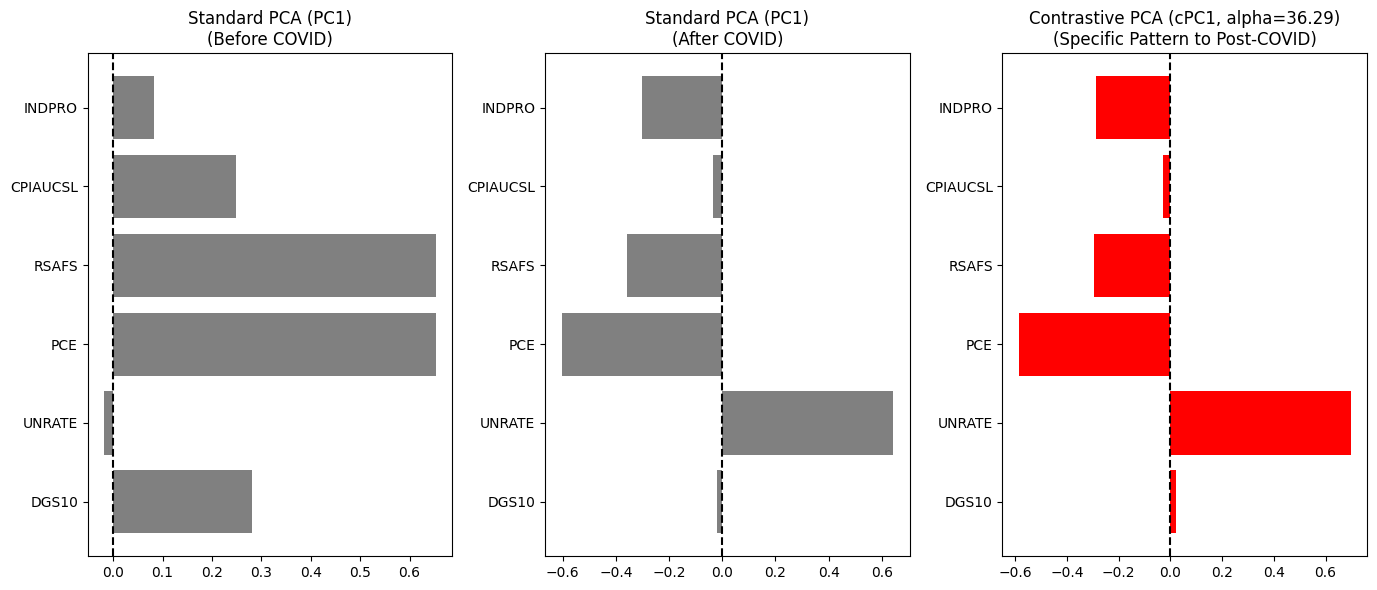

cPCA alpha = 36.29
          Std_PCA before COVID  Std_PCA after COVID  cPCA (alpha=36.29)
Feature                                                                
INDPRO                  0.0826              -0.3016             -0.2894
CPIAUCSL                0.2493              -0.0363             -0.0275
RSAFS                   0.6524              -0.3593             -0.2952
PCE                     0.6530              -0.6041             -0.5853
UNRATE                 -0.0180               0.6428              0.6967
DGS10                   0.2804              -0.0211              0.0210


In [32]:
# 코로나 전/후 분리
split_date = '2020-01-01'
X_bg = df_clean[df_clean.index < split_date]
X_tg = df_clean[df_clean.index >= split_date]

# 배경 데이터 기준으로 스케일링
scaler = StandardScaler()
scaler.fit(X_bg)
X_bg_scaled = scaler.transform(X_bg)
X_tg_scaled = scaler.transform(X_tg)

def run_cpca(background, target):
    """cPCA 수행: alpha는 trace 비율로 자동 결정"""
    cov_tg = np.cov(target, rowvar=False)
    cov_bg = np.cov(background, rowvar=False)
    alpha = np.trace(cov_tg) / np.trace(cov_bg)
    cov_fin = cov_tg - alpha * cov_bg
    vals, vecs = np.linalg.eigh(cov_fin)
    idx = np.argsort(vals)[::-1]
    return vecs[:, idx], vals[idx], alpha

cpca_vecs, cpca_vals, alpha = run_cpca(X_bg_scaled, X_tg_scaled)

# 표준 PCA (코로나 전/후 각각)
pca = PCA(n_components=1)
pca.fit(X_bg_scaled)
pca_vecs1 = pca.components_.T  # 코로나 이전 PC1

pca = PCA(n_components=1)
pca.fit(X_tg_scaled)
pca_vecs2 = pca.components_.T  # 코로나 이후 PC1

# 시각화: Before COVID vs After COVID vs cPCA 비교
features = df_clean.columns
fig, ax = plt.subplots(1, 3, figsize=(14, 6))

ax[0].barh(features, pca_vecs1[:, 0], color='gray')
ax[0].set_title("Standard PCA (PC1)\n(Before COVID)")
ax[0].axvline(0, color='k', linestyle='--')

ax[1].barh(features, pca_vecs2[:, 0], color='gray')
ax[1].set_title("Standard PCA (PC1)\n(After COVID)")
ax[1].axvline(0, color='k', linestyle='--')

ax[2].barh(features, cpca_vecs[:, 0], color='red')
ax[2].set_title(f"Contrastive PCA (cPC1, alpha={alpha:.2f})\n(Specific Pattern to Post-COVID)")
ax[2].axvline(0, color='k', linestyle='--')

for a in ax:
    a.invert_yaxis()

plt.tight_layout()
plt.show()

# 수치 비교
results_df = pd.DataFrame({
    'Feature': features,
    'Std_PCA before COVID': np.round(pca_vecs1[:, 0], 4),
    'Std_PCA after COVID': np.round(pca_vecs2[:, 0], 4),
    f'cPCA (alpha={alpha:.2f})': np.round(cpca_vecs[:, 0], 4)
}).set_index('Feature')

print(f"cPCA alpha = {alpha:.2f}")
print(results_df)

### 결과 해석

cPCA alpha값이 37.35로 매우 높으며, After COVID 표준 PCA와 거의 동일한 패턴이 나타난다.
얼핏 보면 cPCA가 추가적인 정보를 주지 못한 것처럼 보일 수 있으나, 이는 반대로 해석해야 한다.
alpha가 높다는 것은 타겟 국면의 변동성이 배경 국면과 공유하는 구조가 거의 없다는 뜻이고,
PCA와 cPCA 결과가 유사하다는 것은 코로나 충격 자체가 이미 과거 패턴과 완전히 단절된
새로운 구조였음을 의미한다. 즉, cPCA가 제거할 '공통 배경 구조'가 애초에 없었던 것이다.

---
## 3. 연구 2 — 경제 구조 회복 경로 분석

연구 1에서 추출한 코로나 고유 패턴(cPC1)이 실제 시계열에서 언제 소멸했는지,
그리고 경제 구조가 팬데믹 이전으로 언제 복귀했는지를 두 가지 방법으로 정량 분석한다.

- **왜곡 점수 분석**: 현재 데이터를 cPC1 벡터에 투영 → 코로나 충격 패턴의 잔존량 측정
- **코사인 유사도 분석**: 코로나 이전 PC1 벡터와 현재 PC1 벡터의 각도 비교 → 경제 구조의 유사성 측정

코로나 충격 소멸 시점: 2022년 04월


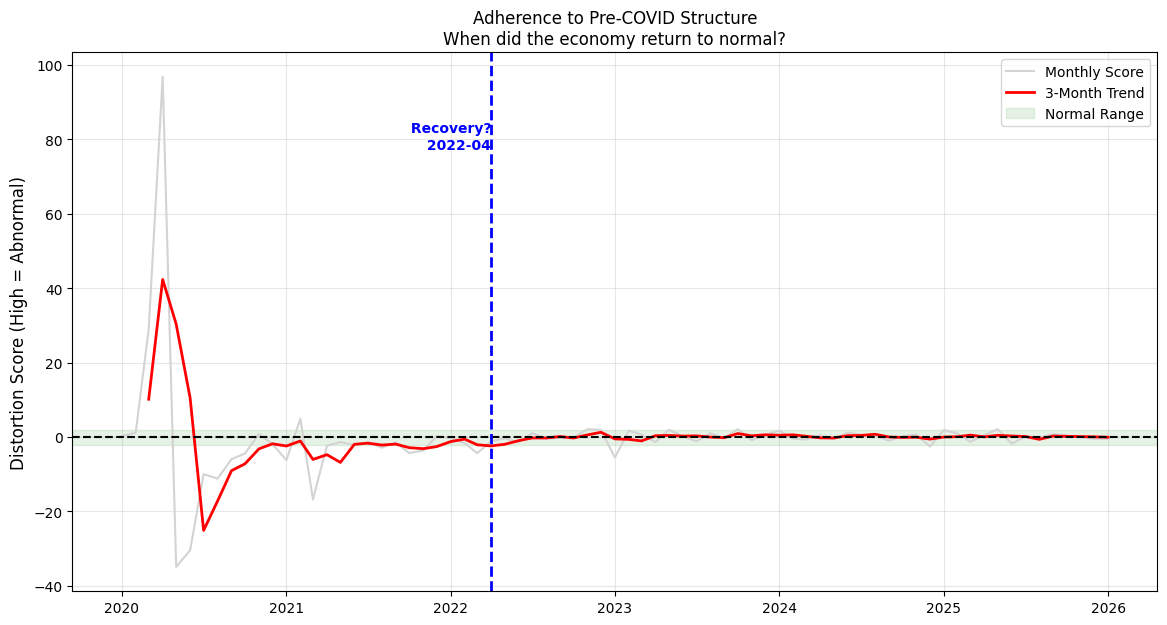

In [28]:
# 왜곡 점수: 코로나 이후 데이터를 cPC1에 투영
scores = X_tg_scaled @ cpca_vecs
proj_tg = pd.Series(scores[:, 0], index=X_tg.index)
proj_tg_roll = proj_tg.rolling(window=3).mean()
threshold = 2

# 3개월 이동평균이 0 근처에 안착한 시점 탐색
recovery_date = None
for date in proj_tg_roll.index[::-1]:
    if abs(proj_tg_roll[date]) > threshold:
        break
recovery_date = date

print(f"코로나 충격 소멸 시점: {recovery_date.strftime('%Y년 %m월')}")

plt.figure(figsize=(14, 7))
plt.plot(proj_tg.index, proj_tg, color='lightgray', label='Monthly Score')
plt.plot(proj_tg_roll.index, proj_tg_roll, color='red', linewidth=2, label='3-Month Trend')
plt.axhspan(-threshold, threshold, color='green', alpha=0.1, label='Normal Range')
plt.axhline(0, color='black', linestyle='--')

if recovery_date:
    plt.axvline(recovery_date, color='blue', linestyle='--', linewidth=2)
    plt.text(recovery_date, max(proj_tg) * 0.8,
             f' Recovery?\n {recovery_date.strftime("%Y-%m")}',
             color='blue', fontweight='bold', ha='right')

plt.title('Adherence to Pre-COVID Structure\nWhen did the economy return to normal?')
plt.ylabel('Distortion Score (High = Abnormal)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

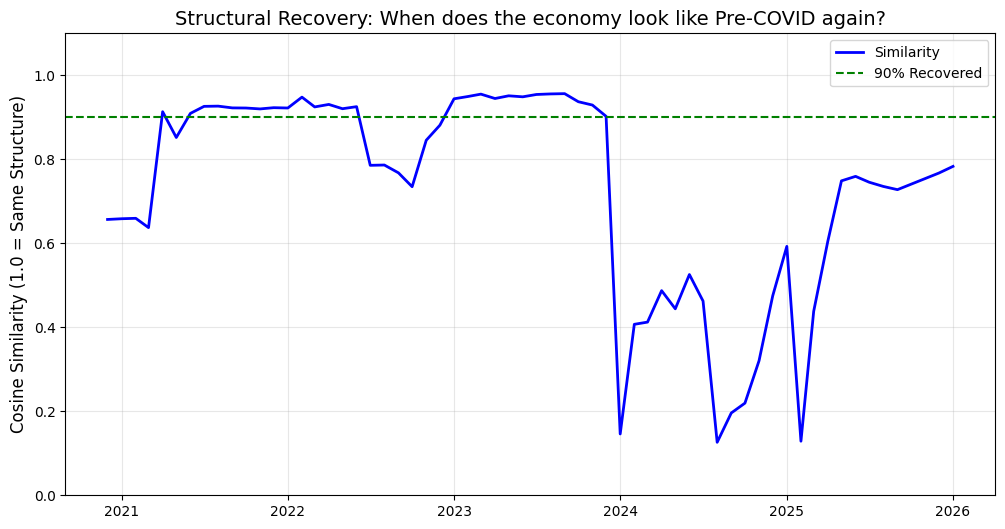

경제 구조 90% 복귀 시점: 2021년 04월


In [29]:
# 코사인 유사도: 코로나 이전 PC1 vs 현재 PC1 비교
window_size = 12
similarities = []
dates = []

for i in range(len(X_tg_scaled) - window_size + 1):
    pca = PCA(n_components=1)
    pca.fit(X_tg_scaled[i:i + window_size])
    pca_vecs_curr = pca.components_[0]
    similarity = abs(np.dot(pca_vecs1.flatten(), pca_vecs_curr))
    similarities.append(similarity)
    dates.append(X_tg.index[i + window_size - 1])

plt.figure(figsize=(12, 6))
plt.plot(dates, similarities, color='blue', linewidth=2, label='Similarity')
plt.axhline(0.9, color='green', linestyle='--', label='90% Recovered')
plt.title('Structural Recovery: When does the economy look like Pre-COVID again?', fontsize=14)
plt.ylabel('Cosine Similarity (1.0 = Same Structure)', fontsize=12)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 코사인 유사도 0.9 첫 도달 시점
sim_series = pd.Series(similarities, index=dates)
recovered_date = None
for date in sim_series.index:
    if sim_series[date] >= 0.9:
        recovered_date = date
        break

print(f'경제 구조 90% 복귀 시점: {recovered_date.strftime("%Y년 %m월")}')

---
## 4. 추가 분석 — AI 시대(2023.10 ~ 2024.10) 경제 구조 변화

코사인 유사도 분석 결과 2024년 초부터 유사도가 0.2~0.4로 급락했다.
이는 코로나 시기와도 다르고, 코로나 이전과도 다른 제3의 경제 구조가 나타났음을 시사한다.

AI 반도체 수요 폭증, 데이터 센터 구축 등이 맞물린 AI 시대(2023.10~2024.10)를
별도로 분리해 cPCA를 적용, 이 시기만의 고유한 경제 패턴을 추출한다.

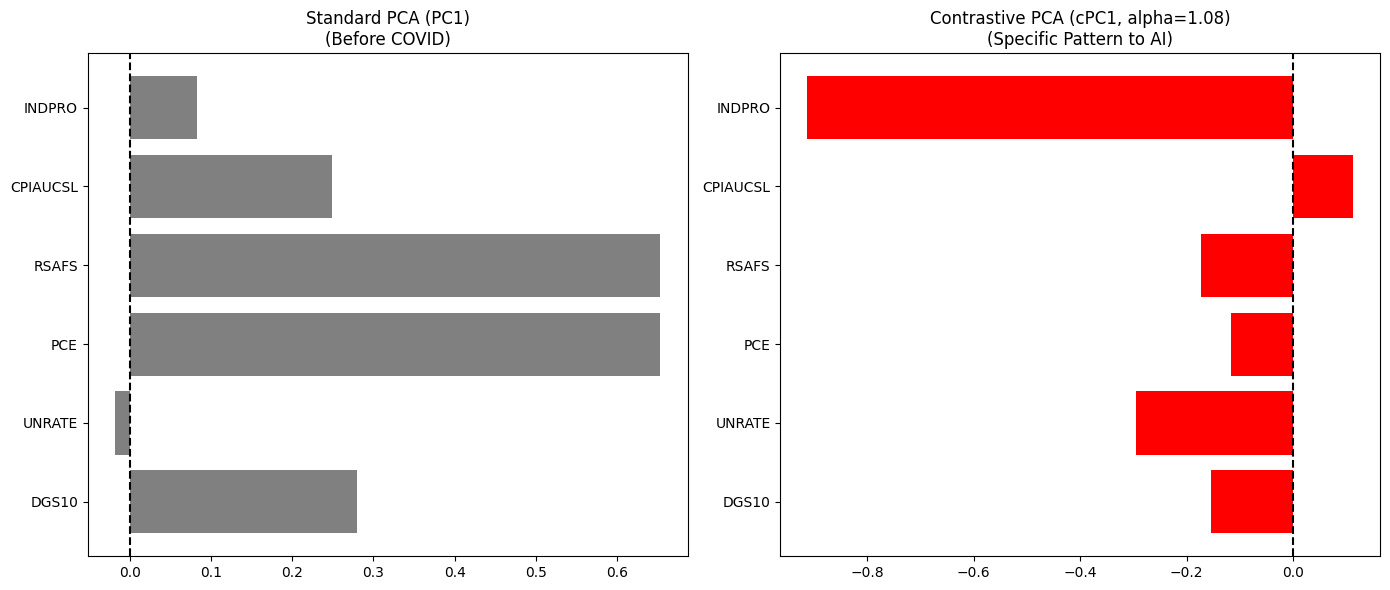

AI 시대 cPCA alpha = 1.08
          Std_PCA before COVID  cPCA AI era (alpha=1.08)
Feature                                                 
INDPRO                  0.0826                   -0.9122
CPIAUCSL                0.2493                    0.1117
RSAFS                   0.6524                   -0.1737
PCE                     0.6530                   -0.1178
UNRATE                 -0.0180                   -0.2954
DGS10                   0.2804                   -0.1553


In [30]:
# AI 시대 구간 분리 및 cPCA 적용
X_ai = df_clean[(df_clean.index > '2023-10-01') & (df_clean.index < '2024-10-01')]
X_ai_scaled = scaler.transform(X_ai)
cpca_ai_vecs, cpca_ai_vals, alpha_ai = run_cpca(X_bg_scaled, X_ai_scaled)

features = df_clean.columns
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].barh(features, pca_vecs1[:, 0], color='gray')
ax[0].set_title("Standard PCA (PC1)\n(Before COVID)")
ax[0].axvline(0, color='k', linestyle='--')

ax[1].barh(features, cpca_ai_vecs[:, 0], color='red')
ax[1].set_title(f"Contrastive PCA (cPC1, alpha={alpha_ai:.2f})\n(Specific Pattern to AI)")
ax[1].axvline(0, color='k', linestyle='--')

for a in ax:
    a.invert_yaxis()

plt.tight_layout()
plt.show()

results_ai = pd.DataFrame({
    'Feature': features,
    'Std_PCA before COVID': np.round(pca_vecs1[:, 0], 4),
    f'cPCA AI era (alpha={alpha_ai:.2f})': np.round(cpca_ai_vecs[:, 0], 4)
}).set_index('Feature')

print(f"AI 시대 cPCA alpha = {alpha_ai:.2f}")
print(results_ai)

---
## 5. 연구 3 — DSSI: 자동 구조 변화 탐지 알고리즘

**문제 의식**: 연구 1~2는 코로나19 발생 시점(2020년 3월)을 사전에 알고 있다는 전제 위에서 분석했다.
하지만 실제로는 충격 시점을 미리 알 수 없다. 어떻게 변곡점 없이 cPCA를 적용할 수 있을까?

**DSSI (Dual-State Structural Index)**:
- 변동성 비율(α = trace(Σ_target) / trace(Σ_background))과 주성분 간 코사인 유사도를 결합한 통합 지수
- `DSSI = (1 + ln(max(α, α⁻¹))) × D` (D = 1 - cosine similarity)
- 로그를 씌운 이유: 변동성 비율의 스케일을 압축해 구조 변화(D)와 균형 유지

**알고리즘 동작 방식**:
1. NORMAL 상태: 배경 데이터를 계속 누적(확장 윈도우), DSSI가 3회 연속 임계값 초과 시 CRISIS로 전환
2. CRISIS 상태: 위기 진입 시점의 충격 벡터(shock_vec)를 고정, 현재 데이터를 투영해 잔존량 계산
3. RECOVERY: 잔존량이 3회 연속 임계값 이하 → 회복 선언, 전체 데이터를 배경으로 재설정

> 위기/회복 모두 단발 판정이 아닌 **3회 연속** 조건을 적용한 이유:
> 월별 데이터 특성상 샘플 수가 적어 노이즈에 의한 오탐 가능성이 높기 때문

In [35]:
def detect_regime_shift(df, initial_bg_size=60, target_size=12, threshold_change=1.0, threshold_recovery=0.8):
    """
    DSSI 기반 자동 구조 변화 탐지 알고리즘

    Parameters
    ----------
    df               : 정상 처리된 다변량 시계열 DataFrame
    initial_bg_size  : 초기 배경 데이터 크기 (default: 60개월)
    target_size      : 롤링 타겟 윈도우 크기 (default: 12개월)
    threshold_change : DSSI 위기 판정 임계값
    threshold_recovery: 회복 판정 잔존 충격 임계값

    Returns
    -------
    DataFrame: 위기/회복 이벤트 목록 (type, date, score)
    """
    if len(df) < initial_bg_size + target_size:
        print('Lack of data')
        return pd.DataFrame()

    events = []
    bg_start_idx = 0
    bg_end_idx = initial_bg_size
    current_idx = bg_end_idx
    state = 'NORMAL'
    shock_vec = None
    change_counter = 0
    recovery_counter = 0

    while current_idx + target_size <= len(df):
        X_bg_raw = df.iloc[bg_start_idx:bg_end_idx]
        X_tg_raw = df.iloc[current_idx:current_idx + target_size]
        curr_date = X_tg_raw.index[-1]

        scaler = StandardScaler()
        X_bg = scaler.fit_transform(X_bg_raw)
        X_tg = scaler.transform(X_tg_raw)

        if state == 'NORMAL':
            cov_bg = np.cov(X_bg, rowvar=False)
            cov_tg = np.cov(X_tg, rowvar=False)

            # DSSI 계산
            alpha = np.trace(cov_tg) / (np.trace(cov_bg) + 1e-9)
            pca_bg = PCA(n_components=1).fit(X_bg)
            pca_tg = PCA(n_components=1).fit(X_tg)
            similarity = np.abs(np.dot(pca_bg.components_[0], pca_tg.components_[0]))
            dissimilarity = 1 - similarity
            alpha_weight = 1 + np.log(max(alpha, 1 / alpha) + 1e-9)
            dssi = alpha_weight * dissimilarity

            # 3회 연속 임계값 초과 시 위기 확정
            if dssi > threshold_change:
                change_counter += 1
            else:
                change_counter = 0

            if change_counter >= 2:
                print(f'[위기 확정] {curr_date.strftime("%Y-%m")} | DSSI: {dssi:.2f} (Alpha:{alpha:.1f}, Sim:{similarity:.2f})')
                state = 'CRISIS'
                events.append({"type": "SHOCK_START", "date": curr_date, "score": dssi})

                # 위기 고유 패턴(충격 벡터) 추출 및 고정
                diff_cov = cov_tg - (alpha * cov_bg)
                vals, vecs = np.linalg.eigh(diff_cov)
                shock_vec = vecs[:, -1]
                change_counter = 0

            if state == 'NORMAL':
                # 정상 상태: 배경 데이터 누적 확장
                bg_end_idx += 1
                current_idx += 1
            else:
                current_idx += 1

        elif state == 'CRISIS':
            # 고정된 충격 벡터에 현재 데이터 투영 → 잔존 충격량 계산
            projection = np.mean(np.abs(X_tg @ shock_vec))

            # 3회 연속 임계값 이하 시 회복 확정
            if projection < threshold_recovery:
                recovery_counter += 1
            else:
                recovery_counter = 0

            if recovery_counter >= 3:
                print(f'[회복 확정] {curr_date.strftime("%Y-%m")} | Residual Shock: {projection:.2f}')
                state = 'NORMAL'
                events.append({"type": "RECOVERY", "date": curr_date, "score": projection})

                # 회복 후 전체 데이터를 배경으로 재설정
                bg_end_idx = current_idx
                recovery_counter = 0

            current_idx += 1

    return pd.DataFrame(events)


events_df = detect_regime_shift(df_clean, initial_bg_size=60, target_size=12, threshold_change=1, threshold_recovery=1.5)
print(events_df)

[위기 확정] 2020-05 | DSSI: 2.03 (Alpha:173.5, Sim:0.67)
[회복 확정] 2022-11 | Residual Shock: 1.03
[위기 확정] 2023-12 | DSSI: 1.46 (Alpha:0.5, Sim:0.12)
[회복 확정] 2024-03 | Residual Shock: 1.01
[위기 확정] 2024-05 | DSSI: 1.76 (Alpha:0.4, Sim:0.09)
[회복 확정] 2024-08 | Residual Shock: 1.10
[위기 확정] 2024-10 | DSSI: 1.67 (Alpha:0.4, Sim:0.15)
[회복 확정] 2025-01 | Residual Shock: 0.92
[위기 확정] 2025-03 | DSSI: 1.93 (Alpha:0.3, Sim:0.08)
[회복 확정] 2025-06 | Residual Shock: 0.84
[위기 확정] 2025-08 | DSSI: 2.42 (Alpha:0.2, Sim:0.03)
[회복 확정] 2026-01 | Residual Shock: 0.53
           type       date     score
0   SHOCK_START 2020-05-01  2.025544
1      RECOVERY 2022-11-01  1.026288
2   SHOCK_START 2023-12-01  1.461085
3      RECOVERY 2024-03-01  1.006866
4   SHOCK_START 2024-05-01  1.760898
5      RECOVERY 2024-08-01  1.099839
6   SHOCK_START 2024-10-01  1.673127
7      RECOVERY 2025-01-01  0.919198
8   SHOCK_START 2025-03-01  1.925251
9      RECOVERY 2025-06-01  0.837923
10  SHOCK_START 2025-08-01  2.421841
11     RECOVER